# **Persiapan Environment & Pembuatan Sinyal 1D**

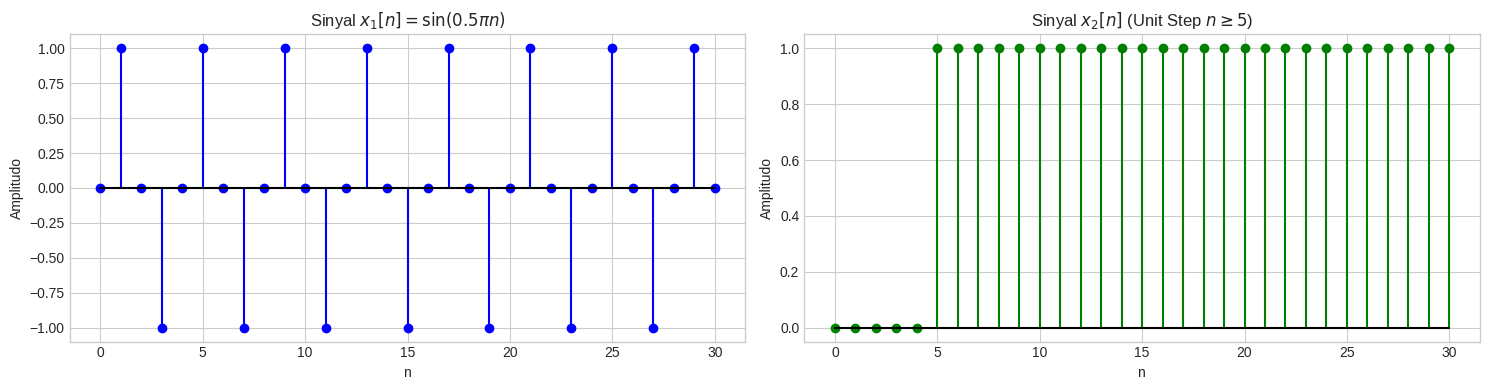

=== Karakteristik Sinyal ===
Sinyal x1[n]: Sinyal periodik osilasi amplitudo antara -1.0 dan 1.0.
Sinyal x2[n]: Sinyal non-periodik diskrit aktif mulai dari indeks n=5.


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Konfigurasi Path Gambar dari Upload Anda
# Silakan sesuaikan path ini dengan lokasi file di Kaggle Input Anda
IMAGE_PATH = 'NB-GN22-3840-2160.jpg' 

# Set style plot agar rapi
if 'seaborn-v0_8-whitegrid' in plt.style.available:
    plt.style.use('seaborn-v0_8-whitegrid')
else:
    plt.style.use('default')

# Definisi rentang nilai n (0 sampai 30)
n = np.arange(0, 31)

# 1. Sinyal Pertama: Sinusoidal
x1 = np.sin(0.5 * np.pi * n)

# 2. Sinyal Kedua: Unit Step (1 untuk n >= 5, 0 untuk n < 5)
x2 = np.where(n >= 5, 1, 0)

# Visualisasi Sinyal Asli
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

ax[0].stem(n, x1, linefmt='b-', markerfmt='bo', basefmt='k-')
ax[0].set_title(r'Sinyal $x_1[n] = \sin(0.5\pi n)$', fontsize=12)
ax[0].set_xlabel('n')
ax[0].set_ylabel('Amplitudo')

ax[1].stem(n, x2, linefmt='g-', markerfmt='go', basefmt='k-')
ax[1].set_title(r'Sinyal $x_2[n]$ (Unit Step $n \geq 5$)', fontsize=12)
ax[1].set_xlabel('n')
ax[1].set_ylabel('Amplitudo')

plt.tight_layout()
plt.show()

print("=== Karakteristik Sinyal ===")
print(f"Sinyal x1[n]: Sinyal periodik osilasi amplitudo antara {x1.min()} dan {x1.max()}.")
print(f"Sinyal x2[n]: Sinyal non-periodik diskrit aktif mulai dari indeks n=5.")

# **Operasi Penjumlahan Sinyal 1D**

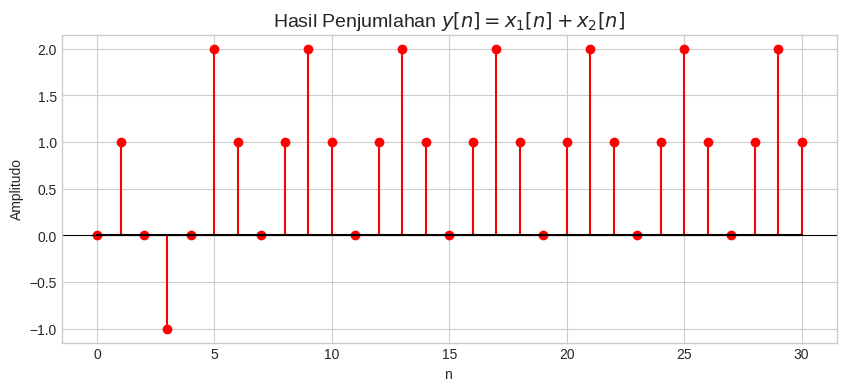

In [55]:
y_add = x1 + x2

plt.figure(figsize=(10, 4))
plt.stem(n, y_add, linefmt='r-', markerfmt='ro', basefmt='k-')
plt.title(r'Hasil Penjumlahan $y[n] = x_1[n] + x_2[n]$', fontsize=14)
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

# **Operasi Penggeseran Sinyal 1D**

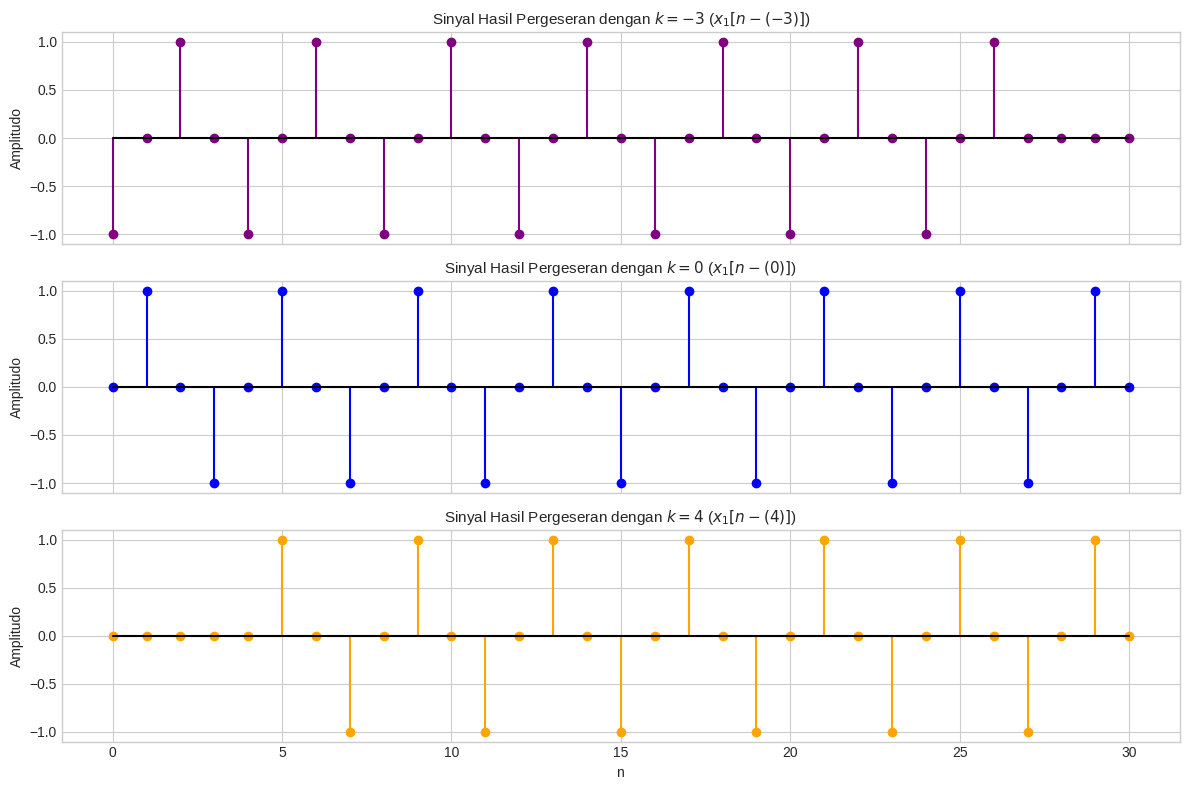

In [56]:
def shift_signal(x, k_val):
    shifted = np.zeros_like(x, dtype=float)
    for idx, ni in enumerate(n):
        src_idx = ni - k_val
        if 0 <= src_idx <= 30:
            shifted[idx] = x[src_idx]
    return shifted

k_values = [-3, 0, 4]
colors = ['purple', 'blue', 'orange']

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, k in enumerate(k_values):
    y_shift = shift_signal(x1, k)
    ax[i].stem(n, y_shift, linefmt=colors[i], markerfmt=colors[i], basefmt='k-')
    ax[i].set_title(r'Sinyal Hasil Pergeseran dengan $k = ' + str(k) + r'$ ($x_1[n - (' + str(k) + r')]$)', fontsize=11)
    ax[i].set_ylabel('Amplitudo')

plt.xlabel('n')
plt.tight_layout()
plt.show()

# **Operasi Amplifikasi Sinyal 1D**

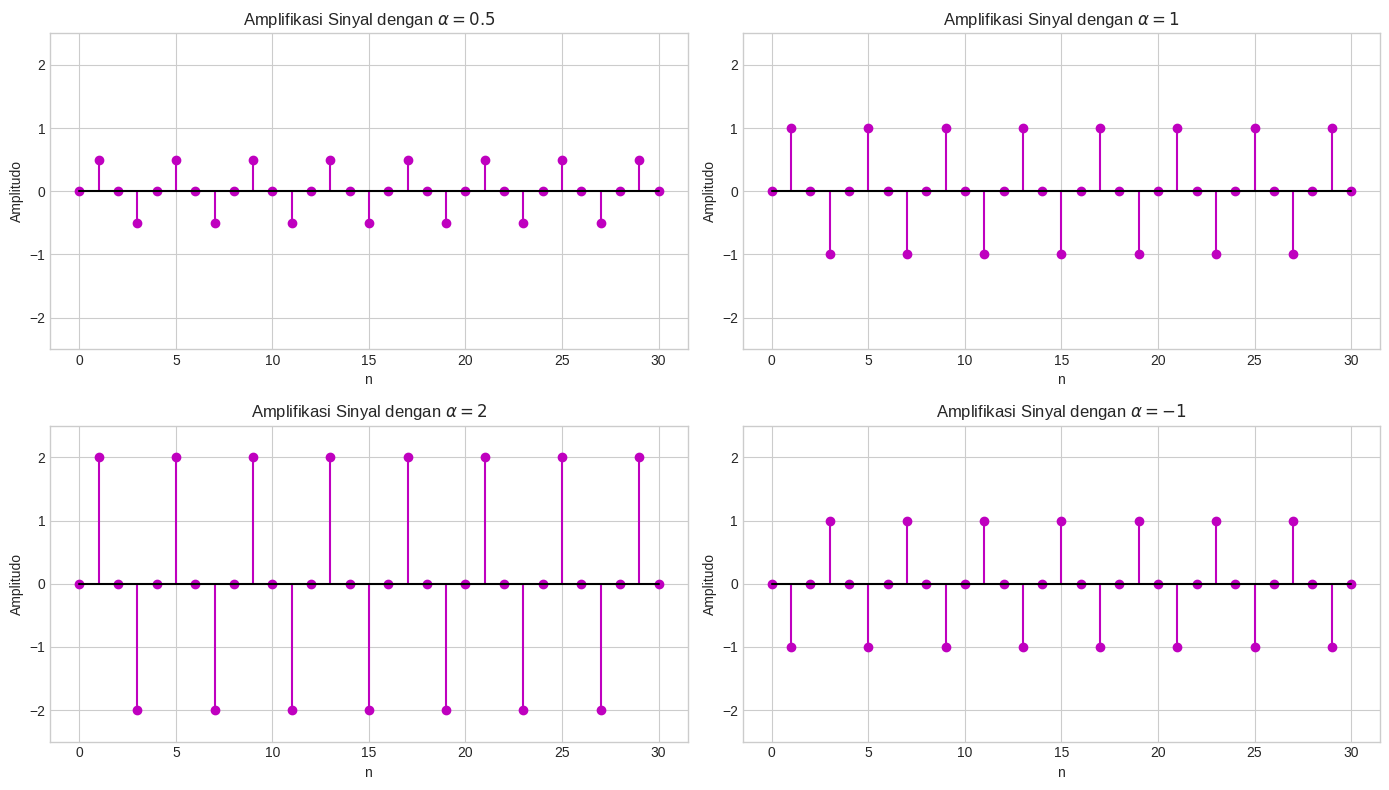

In [57]:
alphas = [0.5, 1, 2, -1]
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax = ax.ravel()

for i, alpha in enumerate(alphas):
    y_amp = alpha * x1
    ax[i].stem(n, y_amp, linefmt='m-', markerfmt='mo', basefmt='k-')
    ax[i].set_title(r'Amplifikasi Sinyal dengan $\alpha = ' + str(alpha) + r'$', fontsize=12)
    ax[i].set_ylim(-2.5, 2.5)
    ax[i].set_xlabel('n')
    ax[i].set_ylabel('Amplitudo')

plt.tight_layout()
plt.show()

# **Operasi Dasar pada Citra 2D**

File 'NB-GN22-3840-2160.jpg' TIDAK ditemukan!

=== META DATA CITRA TUGAS ===
Ukuran Citra (Resolusi Eksperimen): (500, 500)
Tipe Data Array Citra: uint8
Nilai Minimum Piksel: 0
Nilai Maksimum Piksel: 255



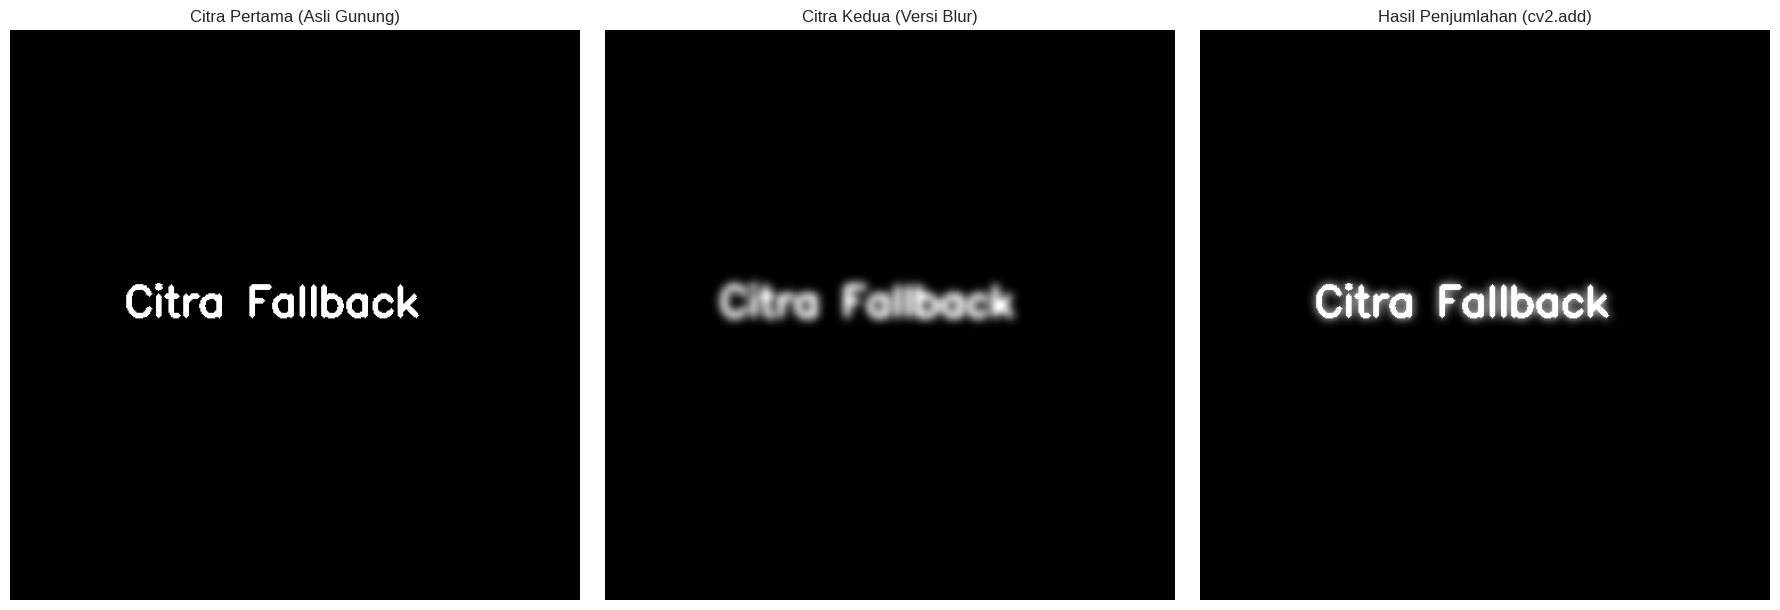

In [58]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMAGE_PATH = 'NB-GN22-3840-2160.jpg' 

# 1. Validasi dan Membaca Gambar
if os.path.exists(IMAGE_PATH):
    citra_asli = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
    if citra_asli is not None:
        citra_asli = cv2.resize(citra_asli, (500, 500))
        print(f"Sukses memuat gambar: {IMAGE_PATH}")
    else:
        print("Gagal membaca gambar. Menggunakan citra fallback.")
        citra_asli = np.uint8(np.random.randint(0, 255, (500, 500)))
else:
    print(f"File '{IMAGE_PATH}' TIDAK ditemukan!")
    citra_asli = np.zeros((500, 500), dtype=np.uint8)
    cv2.putText(citra_asli, 'Citra Fallback', (100, 250), cv2.FONT_HERSHEY_SIMPLEX, 1.2, 255, 3)

# 2. Membuat Citra Kedua dengan ukuran sama (Efek Gaussian Blur)
citra_kedua = cv2.GaussianBlur(citra_asli, (25, 25), 0)

# 3. Operasi Penjumlahan
citra_hasil_penjumlahan = cv2.add(citra_asli, citra_kedua)

# Tampilkan Informasi Meta Citra
print("\n=== META DATA CITRA TUGAS ===")
print(f"Ukuran Citra (Resolusi Eksperimen): {citra_asli.shape}")
print(f"Tipe Data Array Citra: {citra_asli.dtype}")
print(f"Nilai Minimum Piksel: {citra_asli.min()}")
print(f"Nilai Maksimum Piksel: {citra_asli.max()}\n")

# Visualisasi Tiga Panel
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(citra_asli, cmap='gray')
ax[0].set_title('Citra Pertama (Asli Gunung)')
ax[0].axis('off')

ax[1].imshow(citra_kedua, cmap='gray')
ax[1].set_title('Citra Kedua (Versi Blur)')
ax[1].axis('off')

ax[2].imshow(citra_hasil_penjumlahan, cmap='gray')
ax[2].set_title('Hasil Penjumlahan (cv2.add)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# **Penggeseran & Amplifikasi Citra 2D**

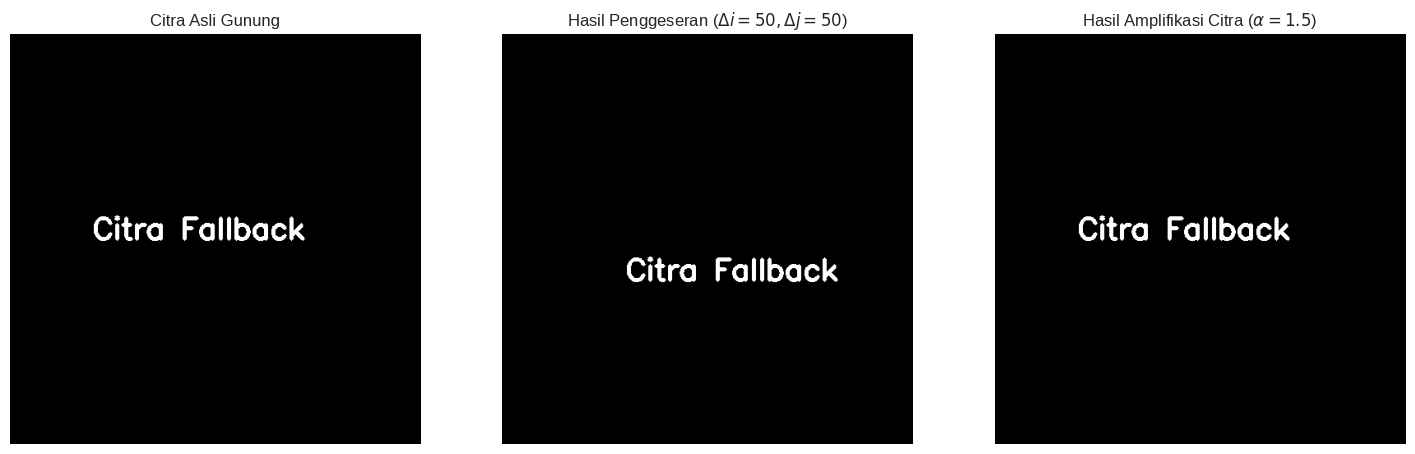

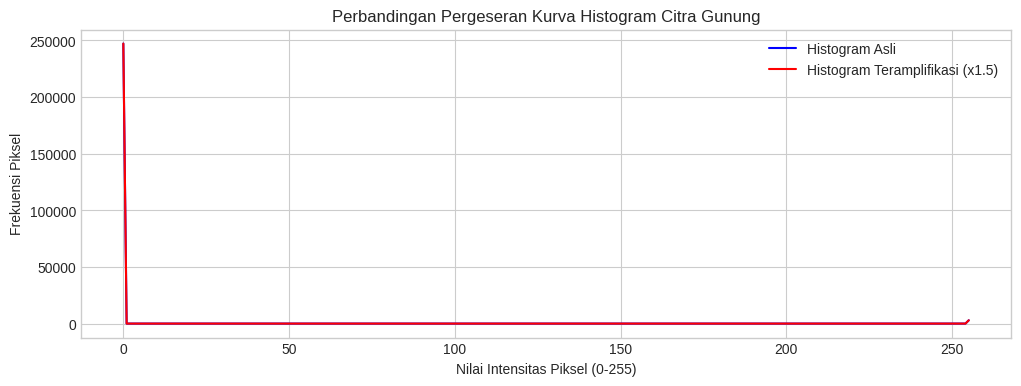

In [59]:
rows, cols = citra_asli.shape

# 1. Operasi Penggeseran Citra (Translasi Delta i = 50, Delta j = 50)
M = np.float32([[1, 0, 50], [0, 1, 50]])
citra_tergeser = cv2.warpAffine(citra_asli, M, (cols, rows))

# 2. Operasi Amplifikasi Citra (Mengalikan intensitas kontras sebesar 1.5x)
alpha_citra = 1.5
citra_teramplifikasi = cv2.convertScaleAbs(citra_asli, alpha=alpha_citra, beta=0)

# Visualisasi Efek Gambar Spasial
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(citra_asli, cmap='gray')
ax[0].set_title('Citra Asli Gunung')
ax[0].axis('off')

ax[1].imshow(citra_tergeser, cmap='gray')
ax[1].set_title(r'Hasil Penggeseran ($\Delta i=50, \Delta j=50$)')
ax[1].axis('off')

ax[2].imshow(citra_teramplifikasi, cmap='gray')
ax[2].set_title(r'Hasil Amplifikasi Citra ($\alpha = 1.5$)')
ax[2].axis('off')
plt.show()

# 3. Analisis Eksperimen Kurva Histogram Citra
plt.figure(figsize=(12, 4))
plt.plot(cv2.calcHist([citra_asli], [0], None, [256], [0, 256]), color='blue', label='Histogram Asli')
plt.plot(cv2.calcHist([citra_teramplifikasi], [0], None, [256], [0, 256]), color='red', label=f'Histogram Teramplifikasi (x{alpha_citra})')
plt.title('Perbandingan Pergeseran Kurva Histogram Citra Gunung')
plt.xlabel('Nilai Intensitas Piksel (0-255)')
plt.ylabel('Frekuensi Piksel')
plt.legend()
plt.show()

# **Pengujian Sifat Sistem Linier**

In [60]:
import pandas as pd

def T1(x_val): return 2 * x_val
def T2(x_val): return x_val ** 2

x_test1 = np.array([2.0, 4.0, 6.0])
x_test2 = np.array([1.0, 3.0, 5.0])
constant_a = 2.5

print("=== HASIL EVALUASI SISTEM LINIER ===")
homo_check_T1 = np.allclose(T1(constant_a * x_test1), constant_a * T1(x_test1))
add_check_T1 = np.allclose(T1(x_test1 + x_test2), T1(x_test1) + T1(x_test2))
print(f"Sistem T1(x) = 2x  -> Homogen: {homo_check_T1} | Additif: {add_check_T1}")

homo_check_T2 = np.allclose(T2(constant_a * x_test1), constant_a * T2(x_test1))
add_check_T2 = np.allclose(T2(x_test1 + x_test2), T2(x_test1) + T2(x_test2))
print(f"Sistem T2(x) = x^2 -> Homogen: {homo_check_T2} | Additif: {add_check_T2}\n")

kesimpulan_data = {
    "Sistem": ["T1(x) = 2x", "T2(x) = x^2"],
    "Homogenitas": ["Memenuhi", "Tidak Memenuhi"],
    "Additivitas": ["Memenuhi", "Tidak Memenuhi"],
    "Linier / Tidak Linier": ["Linier", "Tidak Linier"],
    "Alasan": [
        "Memenuhi kedua prinsip superposisi secara simultan.",
        "Komponen pangkat dua memicu nilai scaling kuadratik (a^2) yang merusak sistem."
    ]
}
pd.DataFrame(kesimpulan_data)

=== HASIL EVALUASI SISTEM LINIER ===
Sistem T1(x) = 2x  -> Homogen: True | Additif: True
Sistem T2(x) = x^2 -> Homogen: False | Additif: False



,Sistem,Homogenitas,Additivitas,Linier / Tidak Linier,Alasan
0,T1(x) = 2x,Memenuhi,Memenuhi,Linier,Memenuhi kedua prinsip superposisi secara simu...
1,T2(x) = x^2,Tidak Memenuhi,Tidak Memenuhi,Tidak Linier,Komponen pangkat dua memicu nilai scaling kuad...
